# Finding rate RNN fixed points

In [ ]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
import sys

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
# import model
from model import generate_input_stim_xor, eval_tf

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import importlib

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/trajectory/fixed_pt/')
import load_RNN_model as lrm

2025-02-27 10:14:17.888086: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-27 10:14:17.896927: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-27 10:14:17.905990: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-27 10:14:17.908681: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-27 10:14:17.916183: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
models_type = 'good_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
RNN_model_file = model_list[0] # just grab the first model

print(f'Loading model: {RNN_model_file}')

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659.mat


In [3]:
rnn_path = os.path.join(models_dir, RNN_model_file) # double check this!!!
model = lrm.load_RNN_model(rnn_path)

In [4]:
print(rnn_path)
print(model)

/scratch/spikeRNN/models/DMS_OSF/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659.mat
tRNN(2, 200)


In [5]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

In [6]:
def generate_xor_type(T, stim_on, stim_dur, delay, stim1=1, stim2=-1):
     
     u = np.zeros((2, T))
     
     u[0, stim_on:stim_on+stim_dur] = stim1
     u[1, stim_on+stim_dur+delay:stim_on+2*stim_dur+delay] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

In [7]:
model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'
print(model_results_dir)

/scratch/spikeRNN/models/DMS_OSF/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659/


In [8]:
n_trials = 1000
stim1s = [-1, 1]
stim2s = [-1, 1]
n_trials_per_condition = int(n_trials/(len(stim1s)*len(stim2s)))

synX = np.zeros((n_trials, settings['T'], 200)) # nTrials x nTimes x nNeurons
trial_stim_labels = np.zeros((n_trials,2))
for i, stim1 in enumerate(stim1s):
    for j, stim2 in enumerate(stim2s):
        for k in range(n_trials_per_condition):
            trial_idx = (i*len(stim2s)+j)*n_trials_per_condition + k

            u, label = generate_xor_type(settings['T'], settings['stim_on'], settings['stim_dur'], settings['delay'], stim1, stim2)
            x, r, o, _ = eval_tf(model_dir=rnn_path, settings=settings, u=u)

            synX[trial_idx,:,:] = x.T
            trial_stim_labels[trial_idx,0] = stim1
            trial_stim_labels[trial_idx,1] = stim2

np.save(f'{model_results_dir}_delay50_synX.npy', synX)
# np.save(f'{model_results_dir}trial_stim_labels.npy', trial_stim_labels)

In [8]:
xx_trials = np.load(f'{model_results_dir}synX.npy')
trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')

In [9]:
stim_on = settings['stim_on']
stim_dur = settings['stim_dur']
delay=settings['delay']
T = settings['T']  


#### for +1 stim

In [10]:
task_type = 1 # for +1 stim
stim1_times = np.arange(stim_on,stim_on+stim_dur)
delay_times = np.arange(stim_on+stim_dur,stim_on+stim_dur+delay)
xx_trials_stim1 = xx_trials[trial_stim_labels[:,0] == task_type,:,:][:,stim1_times,:]
xx_trials_delay = xx_trials[trial_stim_labels[:,0] == task_type,:,:][:,delay_times,:]

print(xx_trials_stim1.shape)
print(xx_trials_delay.shape)

(500, 50, 200)
(500, 50, 200)


In [11]:
n_initial = 200
initial_states = np.zeros((n_initial,xx_trials_delay.shape[2])) # n_initial x nNeurons
# initial_states2 = np.zeros((n_initial,xx_trials_delay.shape[2]))
for iI in np.arange(n_initial):
    rand_trial = np.random.randint(xx_trials_delay.shape[0])
    initial_states[iI,:] = xx_trials_stim1[rand_trial,-1,:]	# last time point of the stimulus
    # initial_states[iI,:] = xx_trials_delay[rand_trial,-2,:]	# second to last time point of the delay period

In [12]:
sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/fixed-point-finder')
from FixedPointFinderTorch import FixedPointFinderTorch as FixedPointFinder
from plot_utils import plot_fps # in fixedpointfinder folder

In [13]:
inputs = np.zeros((1, 2))

# Choosing input vector u for each trial type/modality type		
inputs[0, 0] = 0 # no stim for maintenance period
       
fpf_hps = {
			'max_iters': 30000,
			'lr_init': 0.1,
			'outlier_distance_scale': 10.0,			
			'tol_unique':10, #75
			'verbose': True, 
			'super_verbose': True}

# Defining and running fixed point optimization
fpf = FixedPointFinder(model, **fpf_hps)
unique_fps,all_fps = fpf.find_fixed_points(initial_states, inputs)    
fp_dict = {'xstar': unique_fps.xstar, 'is_stable':unique_fps.is_stable, \
        'J_xstar':unique_fps.J_xstar, 'eigval_J_xstar': unique_fps.eigval_J_xstar, \
            'eigvec_J_xstar':unique_fps.eigvec_J_xstar}


Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 1.60e-02 +/- 2.52e-03, dq = 1.13e-04 +/- 1.58e-05, learning rate = 1.00e-01, avg iter time = 1.10e-03 sec.
	Iter: 200, q = 8.70e-03 +/- 1.73e-03, dq = 5.30e-05 +/- 1.65e-05, learning rate = 1.00e-01, avg iter time = 1.04e-03 sec.
	Iter: 300, q = 4.77e-03 +/- 1.18e-03, dq = 4.94e-05 +/- 9.28e-05, learning rate = 1.00e-01, avg iter time = 1.01e-03 sec.
	Iter: 400, q = 2.51e-03 +/- 7.18e-04, dq = 5.17e-05 +/- 1.31e-04, learning rate = 1.00e-01, avg iter time = 9.93e-04 sec.
	Iter: 500, q = 1.32e-03 +/- 3.77e-04, dq = 1.25e-05 +/- 3.10e-05, learning rate = 9.50e-02, avg iter time = 9.81e-04 sec.
	Iter: 600, q = 7.73e-04 +/- 2.10e-04, dq = 1.48e-05 +/- 7.33e-05, learning rate = 8.57e-02, avg iter time = 9.71e-04 sec.
	Iter: 700, q = 5.00e-04 +/- 1.36e-04, dq = 9.64e-06 +/- 5.29e-05, learning rate 

In [14]:
fp_dict

{'xstar': array([[-3.575422  , -3.467109  , -0.8508117 , -3.3209915 , -2.8113194 ,
         -1.4825099 , -3.657772  , -2.6148443 , -4.2087846 , -2.1360722 ,
         -3.0955167 , -3.0946898 , -4.6711106 , -2.731269  , -1.9593087 ,
         -2.822809  , -4.0479097 , -3.3783202 , -4.0119734 , -2.92906   ,
         -4.226657  , -3.3119001 , -3.874198  , -3.5734787 , -4.2847123 ,
         -3.7002075 , -3.1277704 , -4.0507417 , -2.1657917 , -4.214642  ,
         -4.009958  , -4.3586555 , -4.086663  , -3.2720506 , -1.2116642 ,
         -1.0810789 , -3.6917036 , -2.2879698 , -3.6109781 , -3.1666222 ,
         -1.5137249 , -3.0495088 , -1.9522395 , -4.1499057 , -3.9218946 ,
         -4.0352097 , -4.0956764 , -4.036748  , -3.934281  , -3.927166  ,
         -3.3187919 , -1.5948715 , -1.1267302 , -3.4866583 , -3.9407585 ,
         -2.3264544 , -2.1808639 , -5.378008  , -3.6531494 , -2.4272726 ,
         -3.994222  , -2.9377315 , -1.7080612 , -1.7569592 , -3.551663  ,
         -4.4542255 , -3.9965

In [14]:
xx_trials_thrudelay = xx_trials[:,:stim_on+stim_dur+delay,:] # nTrials x nTimes x nNeurons
pos_fp_dict = fp_dict

#### for -1 stim

In [15]:
task_type = -1 # for -1 stim
stim1_times = np.arange(stim_on,stim_on+stim_dur)
delay_times = np.arange(stim_on+stim_dur,stim_on+stim_dur+delay)
xx_trials_stim1 = xx_trials[trial_stim_labels[:,0] == task_type,:,:][:,stim1_times,:]
xx_trials_delay = xx_trials[trial_stim_labels[:,0] == task_type,:,:][:,delay_times,:]

print(xx_trials_stim1.shape)
print(xx_trials_delay.shape)

(500, 50, 200)
(500, 50, 200)


In [16]:
n_initial = 200
initial_states = np.zeros((n_initial,xx_trials_delay.shape[2])) # n_initial x nNeurons
# initial_states2 = np.zeros((n_initial,xx_trials_delay.shape[2]))
for iI in np.arange(n_initial):
    rand_trial = np.random.randint(xx_trials_delay.shape[0])
    initial_states[iI,:] = xx_trials_stim1[rand_trial,-1,:]	# last time point of the stimulus
    # initial_states[iI,:] = xx_trials_delay[rand_trial,-2,:]	# second to last time point of the delay period

In [17]:
inputs = np.zeros((1, 2))

# Choosing input vector u for each trial type/modality type		
inputs[0, 0] = 0 # no stim for maintenance period
       
fpf_hps = {
			'max_iters': 30000,
			'lr_init': 0.1,
			'outlier_distance_scale': 10.0,			
			'tol_unique':10, #75
			'verbose': True, 
			'super_verbose': True}

# Defining and running fixed point optimization
fpf = FixedPointFinder(model, **fpf_hps)
unique_fps,all_fps = fpf.find_fixed_points(initial_states, inputs)    
fp_dict = {'xstar': unique_fps.xstar, 'is_stable':unique_fps.is_stable, \
        'J_xstar':unique_fps.J_xstar, 'eigval_J_xstar': unique_fps.eigval_J_xstar, \
            'eigvec_J_xstar':unique_fps.eigvec_J_xstar}


Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 5.97e-03 +/- 1.34e-03, dq = 8.33e-05 +/- 2.09e-05, learning rate = 1.00e-01, avg iter time = 1.13e-03 sec.
	Iter: 200, q = 2.22e-03 +/- 6.70e-04, dq = 1.86e-05 +/- 1.20e-05, learning rate = 1.00e-01, avg iter time = 1.03e-03 sec.
	Iter: 300, q = 1.14e-03 +/- 4.20e-04, dq = 9.39e-06 +/- 1.51e-05, learning rate = 1.00e-01, avg iter time = 9.93e-04 sec.
	Iter: 400, q = 6.89e-04 +/- 2.86e-04, dq = 7.79e-06 +/- 2.88e-05, learning rate = 9.02e-02, avg iter time = 9.74e-04 sec.
	Iter: 500, q = 4.83e-04 +/- 2.13e-04, dq = 1.74e-06 +/- 2.22e-06, learning rate = 8.15e-02, avg iter time = 9.62e-04 sec.
	Iter: 600, q = 3.70e-04 +/- 1.67e-04, dq = 1.16e-06 +/- 1.97e-06, learning rate = 7.35e-02, avg iter time = 9.57e-04 sec.
	Iter: 700, q = 2.96e-04 +/- 1.35e-04, dq = 7.01e-07 +/- 1.35e-06, learning rate 

In [18]:
xx_trials_thrudelay = xx_trials[:,:stim_on+stim_dur+delay,:] # nTrials x nTimes x nNeurons
neg_fp_dict = fp_dict

print(xx_trials_thrudelay.shape)

(1000, 300, 200)


#### now PCA

In [25]:
# concatenate trials in time dimension to get a neurons x time matrix

n_neurons = xx_trials_thrudelay.shape[2]
n_times = xx_trials_thrudelay.shape[1]

xx_concatenated = xx_trials_thrudelay.reshape(-1,n_neurons)

# concatenate the fixed points to the trials

xx_concatenated = np.concatenate((xx_concatenated, pos_fp_dict['xstar'],
                                  neg_fp_dict['xstar']),axis=0)
n_pos_fp = pos_fp_dict['xstar'].shape[0]
n_neg_fp = neg_fp_dict['xstar'].shape[0]
n_fixed_pts = n_pos_fp + n_neg_fp
print(n_neg_fp, n_pos_fp, n_fixed_pts)
print(xx_concatenated.shape)

3 3 6
(300006, 200)


In [23]:
# do pca
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca.fit(xx_concatenated)
xx_pca = pca.transform(xx_concatenated)

xx_pca.shape

(300006, 3)

In [32]:
# split up the pca results back into trials
xx_pca_split = xx_pca[:-n_fixed_pts,:]
xx_pca_split = xx_pca_split.reshape(-1,n_times,3)
print(xx_pca_split.shape)

xx_pca_pos_mean = np.mean(xx_pca_split[trial_stim_labels[:,0] == 1],axis=0)
xx_pca_neg_mean = np.mean(xx_pca_split[trial_stim_labels[:,0] == -1],axis=0)

xx_pca_pos = xx_pca_split[trial_stim_labels[:,0] == 1]
xx_pca_neg = xx_pca_split[trial_stim_labels[:,0] == -1]

print(xx_pca_pos_mean.shape)
print(xx_pca_neg_mean.shape)

# un-concatenate fixed points
neg_fixedpt_pca = xx_pca[-n_neg_fp:,:]
pos_fixedpt_pca = xx_pca[-n_fixed_pts:-n_neg_fp,:]

print(neg_fixedpt_pca.shape)
print(pos_fixedpt_pca.shape)

(1000, 300, 3)
(300, 3)
(300, 3)
(3, 3)
(3, 3)


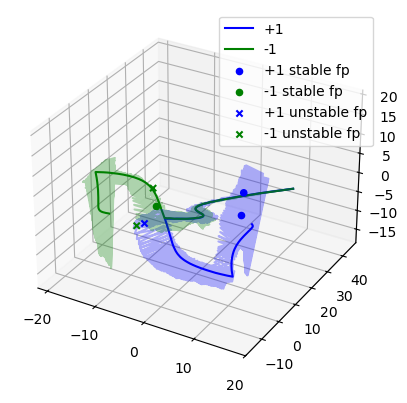

In [37]:
# plot 3d pca

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xx_pca_pos_mean[:,0],xx_pca_pos_mean[:,1],xx_pca_pos_mean[:,2],'b', label='+1')
ax.plot(xx_pca_neg_mean[:,0],xx_pca_neg_mean[:,1],xx_pca_neg_mean[:,2],'g', label= '-1')

# plot random sample from each
n_samples = 5
pos_samp_idx = np.random.randint(xx_pca_pos.shape[0],size=n_samples)
ax.plot(xx_pca_pos[pos_samp_idx,:,0].T,
        xx_pca_pos[pos_samp_idx,:,1].T,
        xx_pca_pos[pos_samp_idx,:,2].T,'b', alpha=0.3)
neg_samp_idx = np.random.randint(xx_pca_neg.shape[0],size=n_samples)
ax.plot(xx_pca_neg[neg_samp_idx,:,0].T,
        xx_pca_neg[neg_samp_idx,:,1].T,
        xx_pca_neg[neg_samp_idx,:,2].T,'g', alpha=0.3)

shapes = ['o','x']
label = ['stable','unstable']
for stability in [0,1]:
    ax.scatter(pos_fixedpt_pca[pos_fp_dict['is_stable']==stability,0],
            pos_fixedpt_pca[pos_fp_dict['is_stable']==stability,1],
            pos_fixedpt_pca[pos_fp_dict['is_stable']==stability,2],
            color='b',marker=shapes[stability], label=f'+1 {label[stability]} fp', alpha=1)
    ax.scatter(neg_fixedpt_pca[neg_fp_dict['is_stable']==stability,0],
            neg_fixedpt_pca[neg_fp_dict['is_stable']==stability,1],
            neg_fixedpt_pca[neg_fp_dict['is_stable']==stability,2],
            color='g',marker=shapes[stability], label=f'-1 {label[stability]} fp', alpha=1)
    
plt.legend()
plt.show()